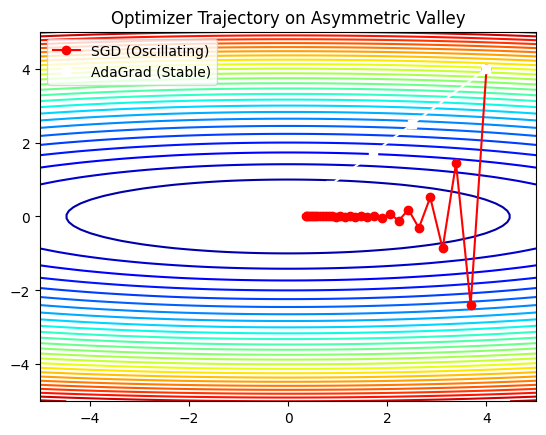

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 손실 함수 정의: y축 경사가 x축보다 20배 가파른 비대칭 골짜기
def loss_func(x, y):
    return 1.0 * (x ** 2) + 20.0 * (y ** 2)

def simulate_optimizer(opt_name, lr=0.1, steps=30):
    # 시작점 설정 (가파른 벽 위쪽)
    w = torch.tensor([4.0, 4.0], requires_grad=True)

    if opt_name == 'sgd':
        optimizer = torch.optim.SGD([w], lr=lr)
    elif opt_name == 'adagrad':
        optimizer = torch.optim.Adagrad([w], lr=lr)

    path = []
    for _ in range(steps):
        path.append(w.detach().clone().numpy())
        loss = loss_func(w[0], w[1])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return np.array(path)

sgd_path = simulate_optimizer('sgd', lr=0.04) # SGD는 lr이 조금만 커도 발산하므로 조절
adagrad_path = simulate_optimizer('adagrad', lr=1.5) # AdaGrad는 가파른 경사를 깎으므로 큰 lr 필요

# 등고선 위에 경로 그리기
x_range = np.linspace(-5, 5, 100)
y_range = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = loss_func(X, Y)

plt.contour(X, Y, Z, levels=30, cmap='jet')
plt.plot(sgd_path[:, 0], sgd_path[:, 1], '-o', color='red', label='SGD (Oscillating)')
plt.plot(adagrad_path[:, 0], adagrad_path[:, 1], '-s', color='white', label='AdaGrad (Stable)')
plt.title('Optimizer Trajectory on Asymmetric Valley')
plt.legend()
plt.show()